In [1]:
# --- Libraries with a short description ---
import pandas as pd # for data manipulation
import matplotlib.pyplot as plt # for plotting
import numpy as np #for numeric calculations and making simulated data.
import seaborn as sns # for plotting, an extension on matplotlib

# - sklearn has many data analysis utility functions like scaling as well as a large variety of modeling tools.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import minmax_scale
from sklearn.preprocessing import scale
from sklearn.manifold import TSNE

# classes and functions for clustering exercises
from matplotlib.patches import Ellipse
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

# This forces plots to be shown inline in the notebook
%matplotlib inline

##  <font color = dimgrey> 1. Introduction to the dataset </font>

This is a toy dataset (datasets that are relatively small and simple, but represent interesting real problems are called "toy datasets") of shopping centre customers. We have demographic information, income, and an attribute called spending score which the shopping centre has calculated from the customers' behaviour.

The exercise data has the following columns/attributes:

| Feature | Type | Explanation |
| :- | :- | :-
| customer_id | - | The identifier of the customer assigned by the mall.
| gender | category | Male/Female. From technical perspective it can also be used as a binary variable.
| age | numeric | The age of the patient in years.
| income | numeric | Yearly income, thousands of dollars.
| spending_score | numeric | Integer 1-100, higher means spends more at shopping centre.

The `customer_id` field is technically a categorical field. However, such fields are rarely used in data science, since they either tell us nothing about the customer, if the customer is new, or tell us too much by uniquely identifying the customer when training machine learning models.

## Reading data

In [2]:

data_path = "shopping_centre.csv" 
data = pd.read_csv(data_path, dtype = {'customer_id':'category',
                                       'gender':'category',
                                       'age': 'int',
                                       'income': 'float',
                                       'spending_score':'int'},)

Normally, customer id would be discarded at this stage. However, in a clustering task, in the end you would be interested which cluster each customer belongs to. So we can keep it even if we do not need it for data analysis.

In [3]:
#print out the first five row of the data
print("First five rows of the data:")
data.head()

First five rows of the data:


,customer_id,gender,age,income,spending_score
0,0001,Male,19,15.0,39
1,0002,Male,21,15.0,81
2,0003,Female,20,16.0,6
3,0004,Female,23,16.0,77
4,0005,Female,31,17.0,40


In [4]:
#2 Create two lists name numeric_features and categorical_features
numeric_features = ["age", "income", "spending_score"]
categorical_features = ["gender"]

In [5]:
#Print the feature types of the dataset
data.dtypes

customer_id       category
gender            category
age                  int64
income             float64
spending_score       int64
dtype: object

In [6]:

data.describe()

,age,income,spending_score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


In [7]:

data[categorical_features].describe()

,gender
count,200
unique,3
top,Female
freq,112


In [8]:
# read in the dataset with no arguments
wrongly_read_data = pd.read_csv(data_path)

# calculate descriptives for the data that was wrongly read in.
wrongly_read_data.describe()

,customer_id,age,income,spending_score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


- Because the data is read without specifying the data types for the feature, particularly here is "customer_id", this feature was also descriptives calculated but in a way for numeric features. At the end we got the result that doesn't bring any value(of "customer_id" column) for data analysis.

- It was important to define the correct data types when loading the data because we can ensure that features like "customer_id" and "gender" are treated as categorical variables, so we obtain meaningful descriptive statistics (unique values, most frequent category, frequency, etc.). Correct data types from the beginning help us gain more useful insights during data analysis.



## Plotting numeric features
Descriptives don't really give a full or intuitive picture of the distribution of features. Next, we will make use of different plots to check the data quality.


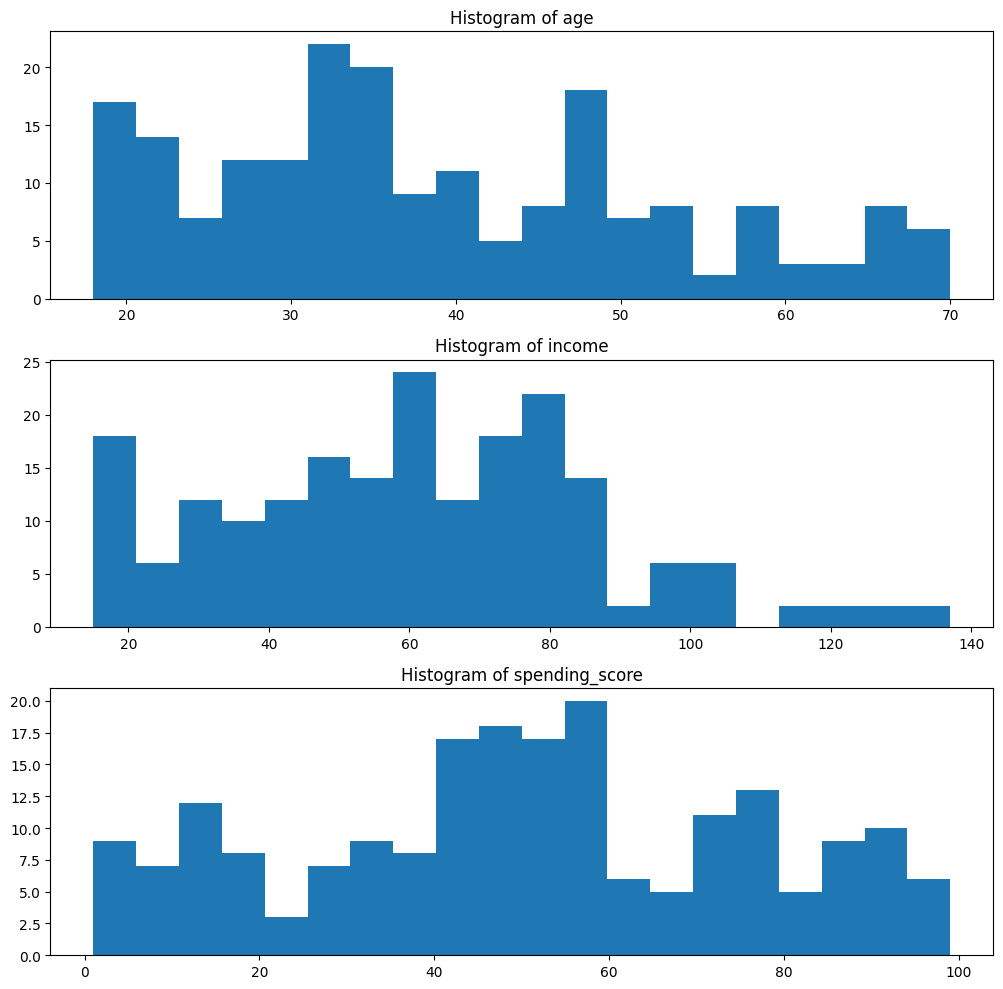

In [9]:
#Plot histograms for the numeric features to visually inspect their distributions.

fig, axes = plt.subplots(len(numeric_features), figsize=(10, 10))

for i, feature in enumerate(numeric_features):
    axes[i].hist(data[feature], bins=20)
    axes[i].set_title(f"Histogram of {feature}")

plt.tight_layout()
plt.show()

## Plotting binary and categorical features

Plot **barplots** for each of the **non-numeric features** in the dataset.

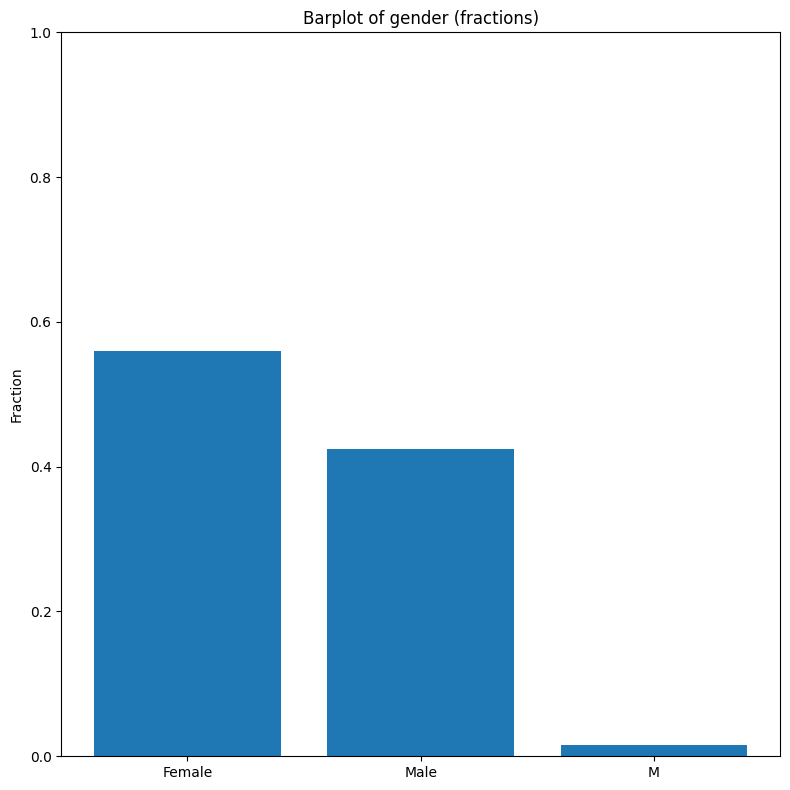

In [10]:
fig, axes = plt.subplots(len(categorical_features), figsize=(8, 8))

# Only one categorical feature -> axes is not a list -> make it a list("customer_id" isn't counted)
if len(categorical_features) == 1:
    axes = [axes]

for i, feature in enumerate(categorical_features):
    fractions = data[feature].value_counts(normalize=True)

    axes[i].bar(fractions.index, fractions.values)
    axes[i].set_title(f"Barplot of {feature} (fractions)")
    axes[i].set_ylabel("Fraction")
    axes[i].set_ylim(0, 1)  # fractions always between 0 and 1

plt.tight_layout()
plt.show()

In [11]:
# remove unnecessary category levels.
 
data["gender"] = data["gender"].cat.remove_categories(["M"])

The following code also works, but Pandas will still assume that "M" is a valid category, causing trouble with e.g. one-hot encoding of features:

In [12]:
data.loc[data["gender"] == "M", "gender"] = "Male"

## Feature generation and exploration

Feature Engineering is a crucial step in the process of preparing data for most data analysis projects. It involves creating new features or modifying existing ones to improve the performance of predictive models. Feature engineering is a combination of domain knowledge, creativity, and data analysis, and it can have a significant impact on the success of a data analysis project.


In [13]:
#Create a feature that puts each customer in a wider age group
bins = [0, 23, 30, 37, 46, 100]
labels = ["under 23", "23-29", "30-36", "37-45", "46+"]

data["age_category"] = pd.cut(data["age"], bins=bins, labels=labels, right=False)

In [14]:
#Similarly to age category, create a wage category feature
bins = [0, 30, 60, 90, 120, 150]
labels = ["under 30", "30-59", "60-89", "90-119", "120+"]

data["income_category"] = pd.cut(data["income"], bins=bins, labels=labels, right=False)


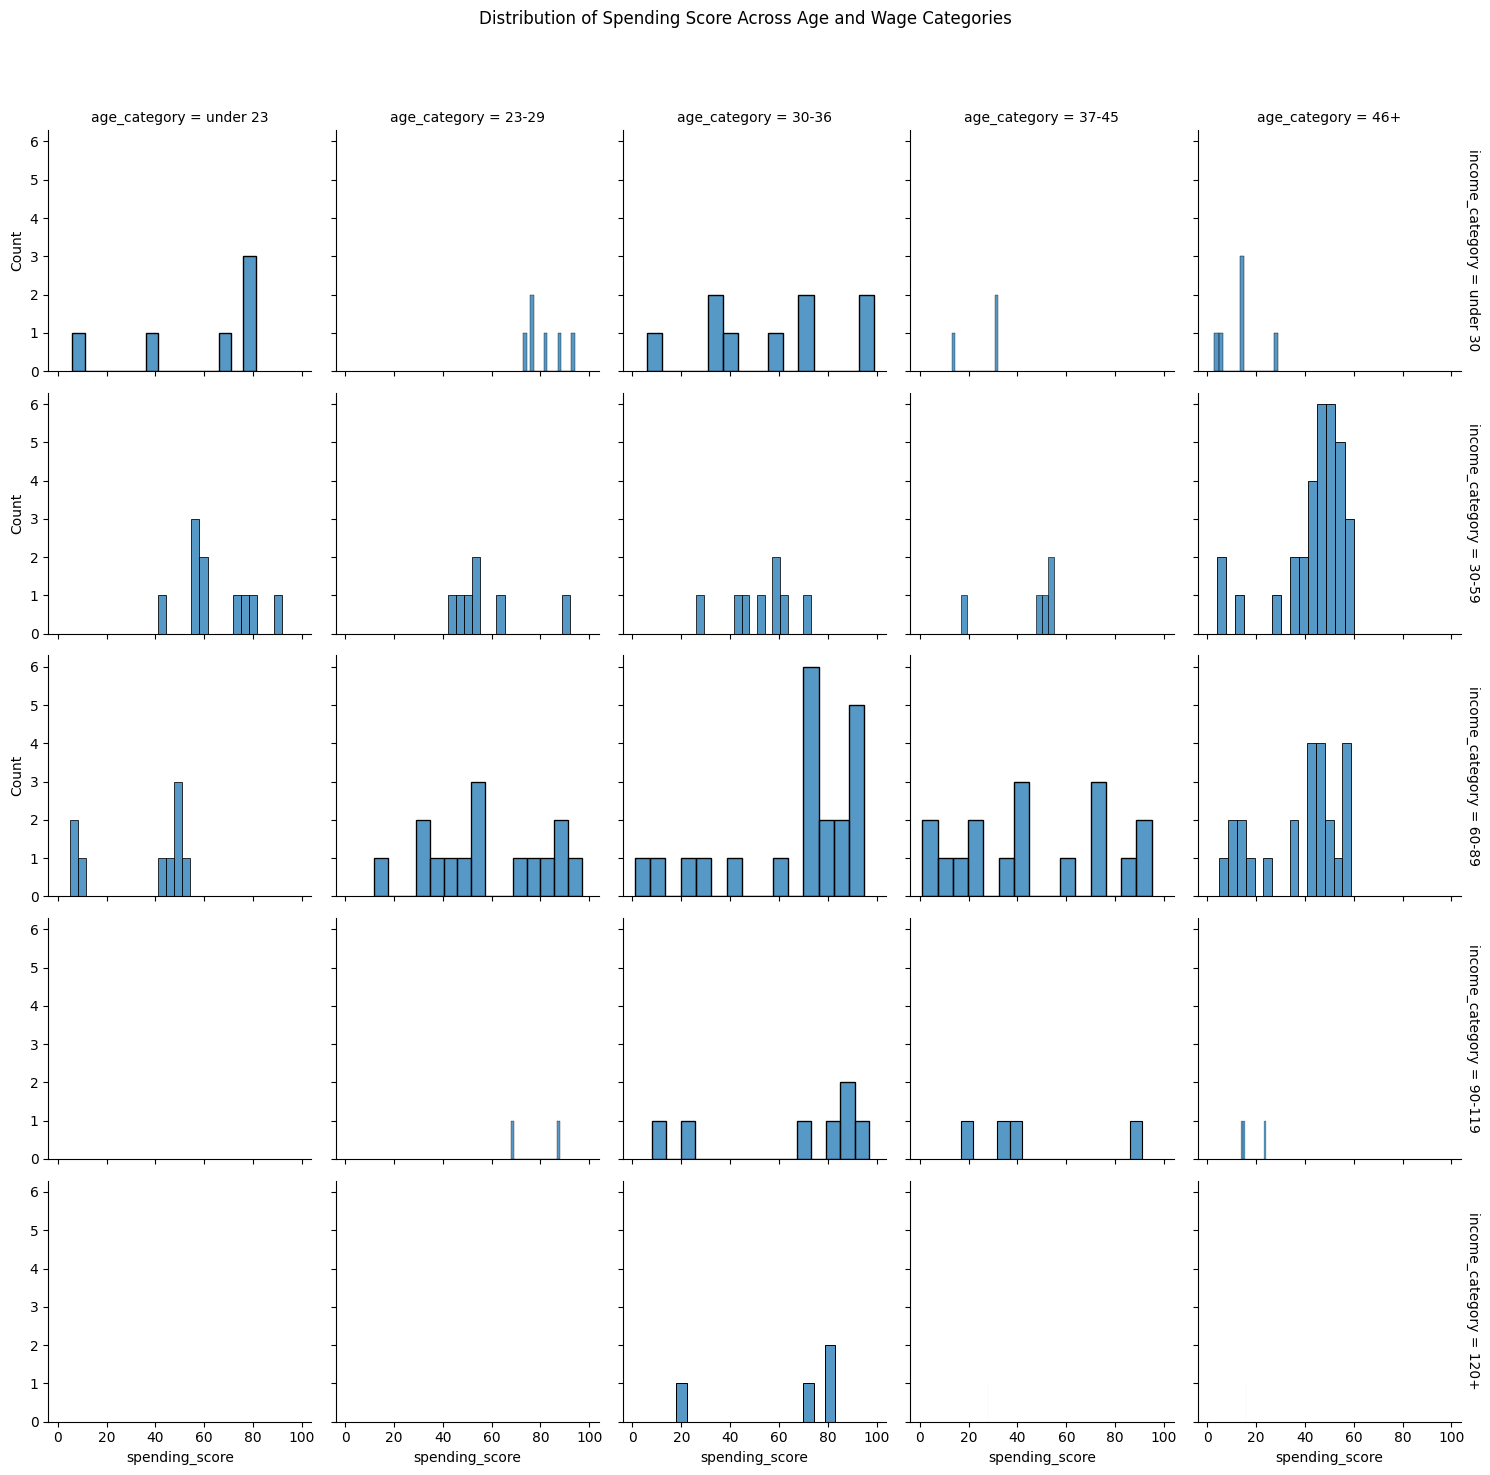

In [15]:
#Create a plot to visualize the distribution of spending score across age and wage categories.
g = sns.FacetGrid(data, col="age_category", row="income_category", margin_titles=True)
g.map_dataframe(sns.histplot, x="spending_score", bins=15)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribution of Spending Score Across Age and Wage Categories")

plt.show()

- People from 30–36 age group has strongest spending behavior, especially among customers earning 60–89k.
- Younger people who are under 23 mostly fall into the lowest income category and spend moderately.
- High-income people 120k+ tend to be older 37+, even though they do not show the highest spending scores.
- The 46+ age group shows the lowest spending activity across wage categories. 

In [16]:
# Add features to column type list 
data['age_category'] = data['age_category'].astype('category')
data['income_category'] = data['income_category'].astype('category')
categorical_features += ["age_category", "income_category"]

## Preprocessing numeric features

Scaling the data is a crucial step in the preprocessing phase of machine learning, as it can significantly improve algorithm performance. In many cases, if scaling is not applied, it may lead to poor performance. This is particularly true for distance-based algorithms covered in the course, such as PCA, t-SNE, KNN and Kmeans where features with larger values can dominate the distance calculations.


In [17]:
# Min-max numeric attributes to [0,1] 
# and **store the results in a new dataframe called data_min_maxed

#apply min-max scaling
scaled_values = minmax_scale(data[numeric_features])

# wrap back into a dataframe
data_min_maxed = pd.DataFrame(scaled_values, columns=numeric_features)

#first 5 rows
data_min_maxed.head()


,age,income,spending_score
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


In [18]:
#Standardize the numeric attributes of the dataset to have a mean of 0 and a standard deviation of 1. 
#Store the standardized results in a new DataFrame called `data_standardized`.

# Standardize numeric features (mean = 0, std = 1)
standardized_values = scale(data[numeric_features])

# Wrap back into a dataframe
data_standardized = pd.DataFrame(standardized_values, columns=numeric_features)

#first 5 rows
data_standardized.head()

,age,income,spending_score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


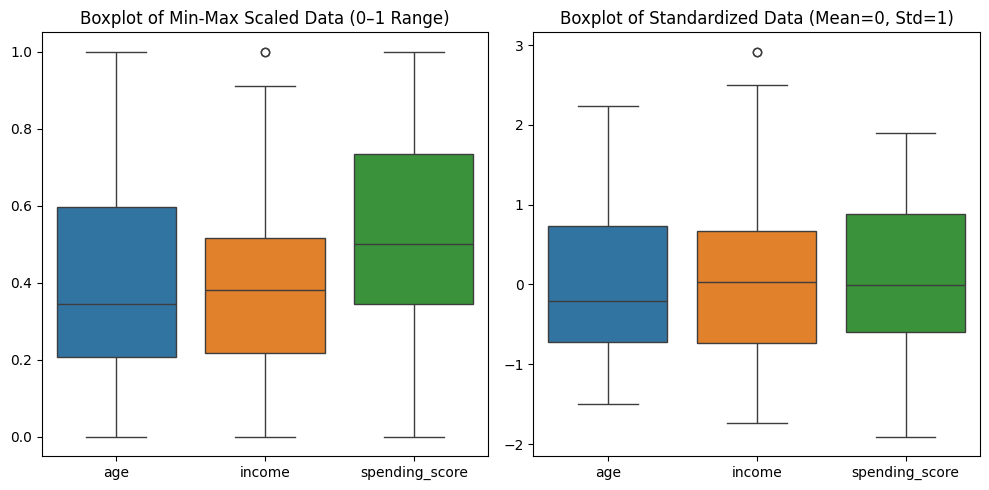

In [19]:
#Create two boxplots for the numeric features: one using the `data_min_maxed` DataFrame
#and the other using the `data_standardized` DataFrame. 
plt.figure(figsize=(10, 5))

# Left: Min-max scaled data
plt.subplot(1, 2, 1)
sns.boxplot(data=data_min_maxed)
plt.title("Boxplot of Min-Max Scaled Data (0–1 Range)")

# Right: Standardized data
plt.subplot(1, 2, 2)
sns.boxplot(data=data_standardized)
plt.title("Boxplot of Standardized Data (Mean=0, Std=1)")

plt.tight_layout()
plt.show()

- Min-Max Scaled Boxplot (0–1 range): All features will be squeezed into the 0 to 1 range; The quartiles (Q1, median, Q3) of each feature will fall somewhere in that range; The shape of each distribution stays the same; Outliers will appear closer to 0 or 1 because the scaling compresses everything.

- Standardized Boxplot (mean = 0, std = 1): Each feature will be centered around 0; The median should be near 0 but not necessarily exactly 0; The interquartile range will be around –1 to +1 depending on distribution; the outliers may appear a little bit farther away because standardization does not compress the range.

In [20]:
### Add an outlier
data_w_outlier = data.copy() #data should be the name of the variable where you have stored your data!
data_w_outlier.loc[data.shape[0] -1 , 'age'] = 150 #change the last value of age to be 150
age_w_outlier = data_w_outlier.age

In [ ]:
# Min-max scale the age feature with an outlier
age_w_outlier_minmaxed = minmax_scale(age_w_outlier)

# Standardize the same feature
age_w_outlier_standardized = scale(age_w_outlier)

In [22]:
age_w_outlier_minmaxed

array([0.00757576, 0.02272727, 0.01515152, 0.03787879, 0.09848485,
       0.03030303, 0.12878788, 0.03787879, 0.34848485, 0.09090909,
       0.37121212, 0.12878788, 0.3030303 , 0.04545455, 0.14393939,
       0.03030303, 0.12878788, 0.01515152, 0.25757576, 0.12878788,
       0.12878788, 0.0530303 , 0.21212121, 0.09848485, 0.27272727,
       0.08333333, 0.20454545, 0.12878788, 0.16666667, 0.03787879,
       0.31818182, 0.02272727, 0.26515152, 0.        , 0.23484848,
       0.02272727, 0.18181818, 0.09090909, 0.13636364, 0.01515152,
       0.35606061, 0.04545455, 0.22727273, 0.09848485, 0.23484848,
       0.04545455, 0.24242424, 0.06818182, 0.08333333, 0.09848485,
       0.23484848, 0.11363636, 0.09848485, 0.31060606, 0.24242424,
       0.21969697, 0.25      , 0.38636364, 0.06818182, 0.26515152,
       0.39393939, 0.00757576, 0.37121212, 0.27272727, 0.34090909,
       0.        , 0.18939394, 0.37878788, 0.00757576, 0.10606061,
       0.39393939, 0.21969697, 0.31818182, 0.31818182, 0.31060

In [23]:
age_w_outlier_standardized

array([-1.2801832 , -1.15498191, -1.21758255, -1.02978062, -0.52897545,
       -1.09238126, -0.27857287, -1.02978062,  1.53684585, -0.5915761 ,
        1.72464778, -0.27857287,  1.16124197, -0.96717997, -0.15337158,
       -1.09238126, -0.27857287, -1.21758255,  0.7856381 , -0.27857287,
       -0.27857287, -0.90457933,  0.41003423, -0.52897545,  0.91083939,
       -0.65417674,  0.34743358, -0.27857287,  0.03443035, -1.02978062,
        1.28644326, -1.15498191,  0.84823875, -1.34278384,  0.59783616,
       -1.15498191,  0.15963165, -0.5915761 , -0.21597223, -1.21758255,
        1.59944649, -0.96717997,  0.53523552, -0.52897545,  0.59783616,
       -0.96717997,  0.66043681, -0.77937804, -0.65417674, -0.52897545,
        0.59783616, -0.40377416, -0.52897545,  1.22384262,  0.66043681,
        0.47263487,  0.72303745,  1.84984907, -0.77937804,  0.84823875,
        1.91244972, -1.2801832 ,  1.72464778,  0.91083939,  1.4742452 ,
       -1.34278384,  0.22223229,  1.78724843, -1.2801832 , -0.46

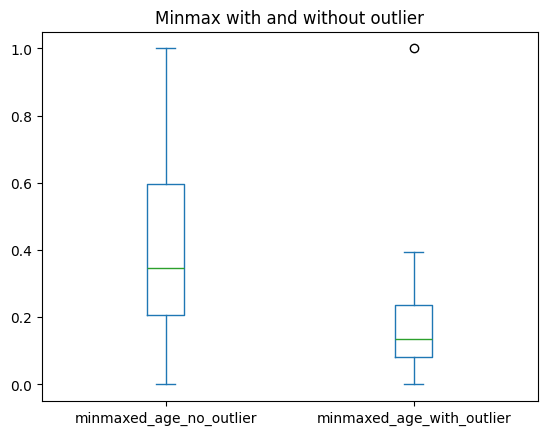

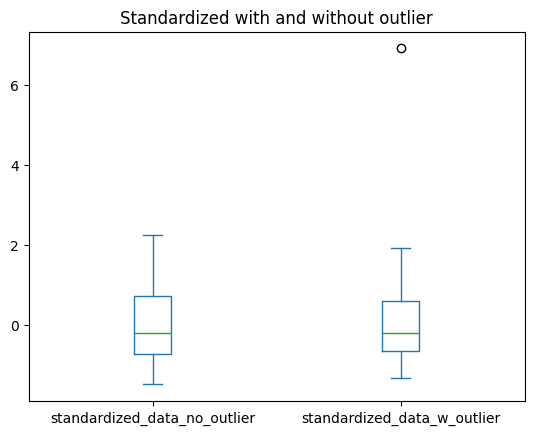

In [24]:
# PLOT
# Wrap in a dataframe that will have two features - the age feature without the outlier, and the age feature with it, min-maxed.
minmaxed_outlier_example = pd.DataFrame({"minmaxed_age_no_outlier" : data_min_maxed.age,
              "minmaxed_age_with_outlier": age_w_outlier_minmaxed })

# Wrap in a dataframe that will have two features - the age feature without the outlier, and the age feature with it, standardized.
standardized_outlier_example = pd.DataFrame({"standardized_data_no_outlier" : data_standardized.age,
              "standardized_data_w_outlier": age_w_outlier_standardized })

axes_minmaxed = minmaxed_outlier_example[['minmaxed_age_no_outlier', 'minmaxed_age_with_outlier']].plot(kind='box', title='Minmax with and without outlier')
axes_std = standardized_outlier_example[['standardized_data_no_outlier', 'standardized_data_w_outlier']].plot(kind='box', title='Standardized with and without outlier')

A difference between the two cases (min-maxed and standardized):
- With min-max scaled version, almost all the values get squeezed between 0 and about 0.4, and the outlier is 1.0. Everything becomes very tightly packed because the outlier forces the whole range to stretch.

- With the standardized version, the values look more spread out around 0, and the outlier becomes a very big positive number instead of "1" like the min-max scaled version. The distribution looks more natural, and the other values are not squeezed together.


The difference of the effect of min-maxing and standardization:

- Min-max scaling is very sensitive to outliers. If there is even one very large value, it will become 1, and all the other values will be pushed closer to 0. This makes the data lose a lot of its original shape.

- Standardization behaves much better when outliers are present. It doesn’t squash everything into a tiny range. Instead, it keeps the overall structure of the data: the average stays around 0, most values stay within a few standard deviations, and the outlier then becomes a very large z-score.

## Agglomerative hierarchical clustering

Our earlier exploration already showed patterns in customer behavior, related to their demographics. This was based on handcrafted features that came from our expert knowledge - we can expect specific behaviours based on income and age. However, assuming some patterns exist, trying to find them automatically would also work if we _do not_ have this expert knowledge, also it may find things that go contrary to our assumptions. This is what unsupervised learning is about.

Start by plotting spending score (color) against age/income to have another look at how these attributes are related.


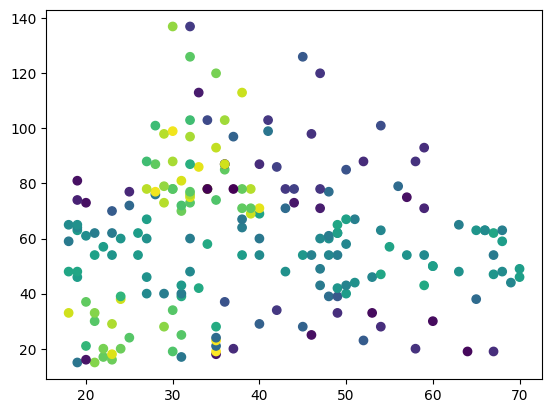

In [25]:

fig, ax = plt.subplots()
ax.scatter(data["age"], data["income"], c=data["spending_score"])


Cluster the standardized data into 2-10 clusters using agglomerative hierarchical clustering. Observe that spending score is one of the input variables - this is not a mistake, we're not trying to do supervised learning here.

- Explore all combinations of the **number of clusters** (2-10) and the **linkage criteria**.
- Calculate the silhouette coefficient for each combination and store the results, as well as the predictions made by the clustering.


In [26]:

linkage_methods = ["ward", "complete", "average", "single"]

# Dictionary to store results
results = []

X = data_standardized  # standardized data from earlier

for n_clusters in range(2, 11):  # 2 to 10 clusters
    for linkage in linkage_methods:

        # Ward linkage requires Euclidean distance & cannot be used with non-Euclidean metrics
        if linkage == "ward":
            model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)
        else:
            model = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage)

        # Fit model
        labels = model.fit_predict(X)

        # Compute silhouette score
        score = silhouette_score(X, labels)

        # Store results
        results.append({
            "num_of_clusters": n_clusters,
            "linkage": linkage,
            "silhouette_score": score,
            "labels": labels
        })


- Use the silhouette score to determine the best linkage criterion for each number of clusters (2-10).
- For each number of clusters, display the best linkage criterion and the silhouette score, sorted by the score (high to low) as follows:

| Number of clusters | Linkage criterion | Silhouette score
| --- | --- | ---   

In [27]:
# Convert list of dictionaries to dataframe
results_df = pd.DataFrame(results)

# Find best linkage per number of clusters
best_per_k = (
    results_df
    .sort_values("silhouette_score", ascending=False)
    .groupby("num_of_clusters")
    .first()
    .reset_index()
)

# Display in required format
best_per_k[["num_of_clusters", "linkage", "silhouette_score"]]

,num_of_clusters,linkage,silhouette_score
0,2,average,0.324936
1,3,average,0.339962
2,4,complete,0.390139
3,5,average,0.409569
4,6,ward,0.420117
5,7,ward,0.398295
6,8,average,0.375567
7,9,average,0.406859
8,10,average,0.395443


## Cluster visualization


For visualization, project the data to two dimensions by using principal component analysis (PCA). These principal components are solely used for plotting the data. The clusterings are done on the original standardized features.

In [28]:
# Use only standardized features
X = data_standardized

# Project the data to two dimensions by using PCA
pca = PCA(n_components=2)

# Fit PCA and transform the data
X_pca = pca.fit_transform(X)

# Turn into a DataFrame for easier plotting later
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

# Preview the first few rows
pca_df.head()


,PC1,PC2
0,-0.615720,-1.763481
1,-1.665793,-1.820747
2,0.337862,-1.674799
3,-1.456573,-1.772430
4,-0.038465,-1.662740



Create a scatter plot of the data in the 2-dimensional projection created by the PCA.

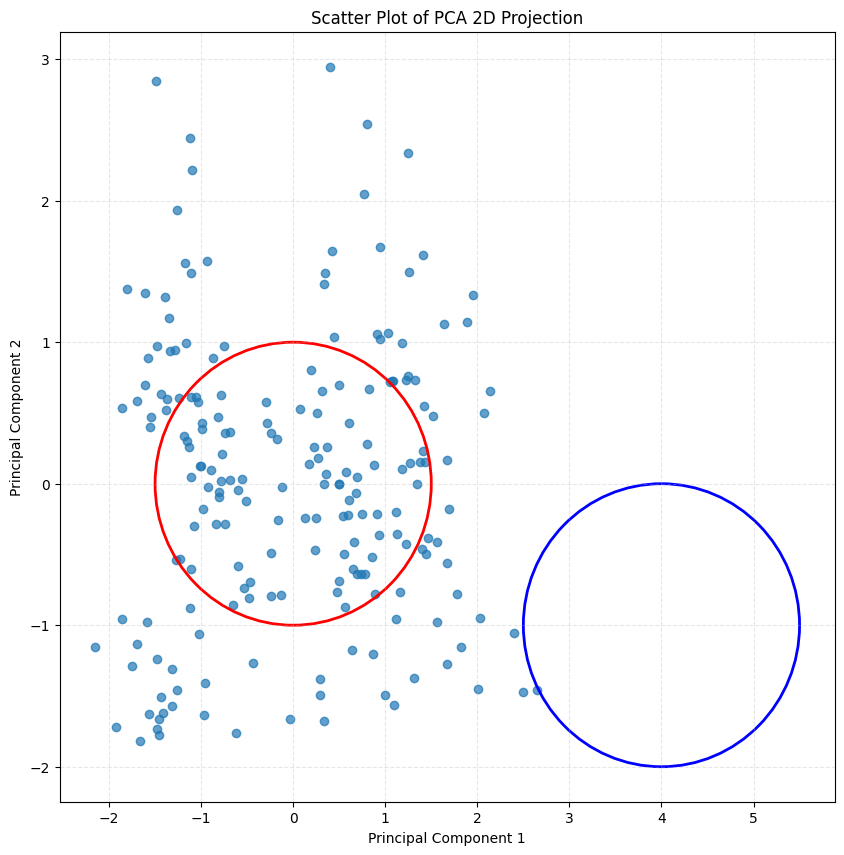

In [29]:
plt.figure(figsize=(10, 10))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.7)

# Using Ellipse because it is imported from the beginning
ellipse1 = Ellipse(xy=(0, 0), width=3, height=2, angle=0,
                   edgecolor='red', facecolor='none', linewidth=2)
ellipse2 = Ellipse(xy=(4, -1), width=3, height=2, angle=0,
                   edgecolor='blue', facecolor='none', linewidth=2)

plt.gca().add_patch(ellipse1)
plt.gca().add_patch(ellipse2)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Scatter Plot of PCA 2D Projection")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


- Plot four clusterings with **five clusters**, one of each **linkage criterion**, as scatter plots.
 - use the first two PCs for visualization. 
 - Colour the datapoints according to the clusters they were assigned to.


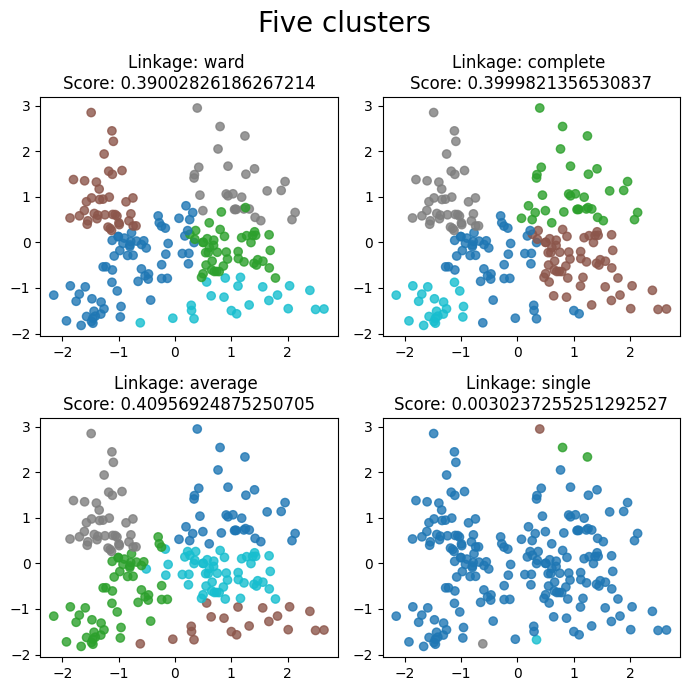

In [30]:
# outline for the plots(from this line is the provided code)
fig, axes = plt.subplots(2,2, figsize=(7,7))
fig.suptitle("Five clusters", fontsize=20)

axes = axes.flatten() # creates a single array from a 2D-matrix

for i, ax in enumerate(axes):
    # linkage=
    linkage = linkage_methods[i]
    
    # clustering
    model = AgglomerativeClustering(n_clusters=5, linkage=linkage)
    labels = model.fit_predict(data_standardized)

    # scatter plot the data points in the PCA space, set color by cluster
    # silhouette score
    score = silhouette_score(data_standardized, labels)

    ax.scatter(pca_df["PC1"], pca_df["PC2"], c=labels, cmap="tab10", alpha=0.8)

    # score=
    ax.set_title(f"Linkage: {linkage} \nScore: {score}")

plt.tight_layout()

#show
plt.show()


Effect of number of clusters:

From the clusterings using **'ward'** linkage criterion, plot the four clusterings of best performing **number of clusters** as scatter plots. Use the same style of 2x2 axes plot.

In [31]:
#filter only results using Ward linkage
ward_results = [res for res in results if res["linkage"] == "ward"]

#sort by silhouette score (best first)
ward_results_sorted = sorted(ward_results, key=lambda x: x["silhouette_score"], reverse=True)

#select the top 4 best-performing clusterings
best_ward = ward_results_sorted[:4]


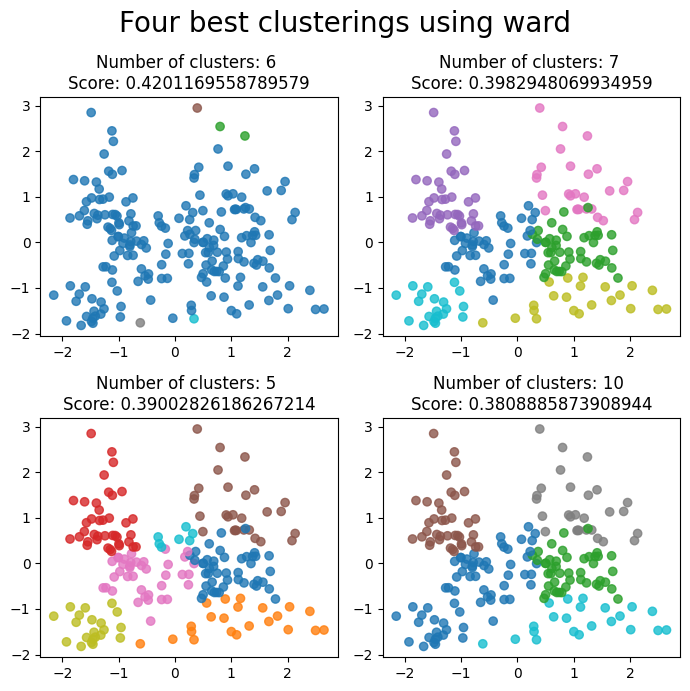

In [32]:
# outline for the plots
fig, axes = plt.subplots(2,2, figsize=(7,7))
fig.suptitle("Four best clusterings using ward", fontsize=20)

axes = axes.flatten() # creates a single array from a 2D-matrix

for i, ax in enumerate(axes):
    # scatter plot the data points in the PCA space, set color by cluster
    ax.scatter(pca_df["PC1"], pca_df["PC2"], c=labels, cmap="tab10", alpha=0.8)

    #label
    labels = best_ward[i]["labels"]
    # n_clust
    n_clust = best_ward[i]["num_of_clusters"]
    # score
    score = best_ward[i]["silhouette_score"]
    
    ax.set_title(f"Number of clusters: {n_clust} \nScore: {score}")

plt.tight_layout()

#show
plt.show()

I somehow agree with the silhouette score results, because some clusterings appear more separated in the projection and match the higher scores. But the PCA plot sometimes makes clusters look closer than they actually are in the full feature space. Personally I think this can make a clustering with a high silhouette score look less convincing (visually).

##  _k_-means clustering


- Perform _k_-means clustering on the standardized data. Try 2-10 numbers of clusters.
- Evaluate the clustering performance using the silhouette coefficient.
- Store the centroids of the clusters

In [33]:

k_values = range(2, 11)
sil_scores = []
centroid_dict = {}

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_standardized)
    
    score = silhouette_score(data_standardized, labels)
    sil_scores.append((k, score))
    
    # store centroids (in standardized feature space)
    centroid_dict[k] = kmeans.cluster_centers_
    
sil_scores

[(2, 0.33547192894004574),
 (3, 0.3579234303882264),
 (4, 0.4039582785148566),
 (5, 0.40846873777345605),
 (6, 0.43106526216603014),
 (7, 0.410091114520974),
 (8, 0.3673663165322295),
 (9, 0.37442148555078425),
 (10, 0.36186970479722974)]


 - Choose the four best numbers of clusters according to silhouette coefficient that you discovered above.
 - Once again visualize them on a scatter plot of the first two principal components.
 - Display the centroids of the clusters on the plot.
 - Transform the centroids to the 2-d projected space.



In [34]:

#get top 4 cluster counts
top4 = sorted(sil_scores, key=lambda x: x[1], reverse=True)[:4]
top4_k = [k for k, s in top4]

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


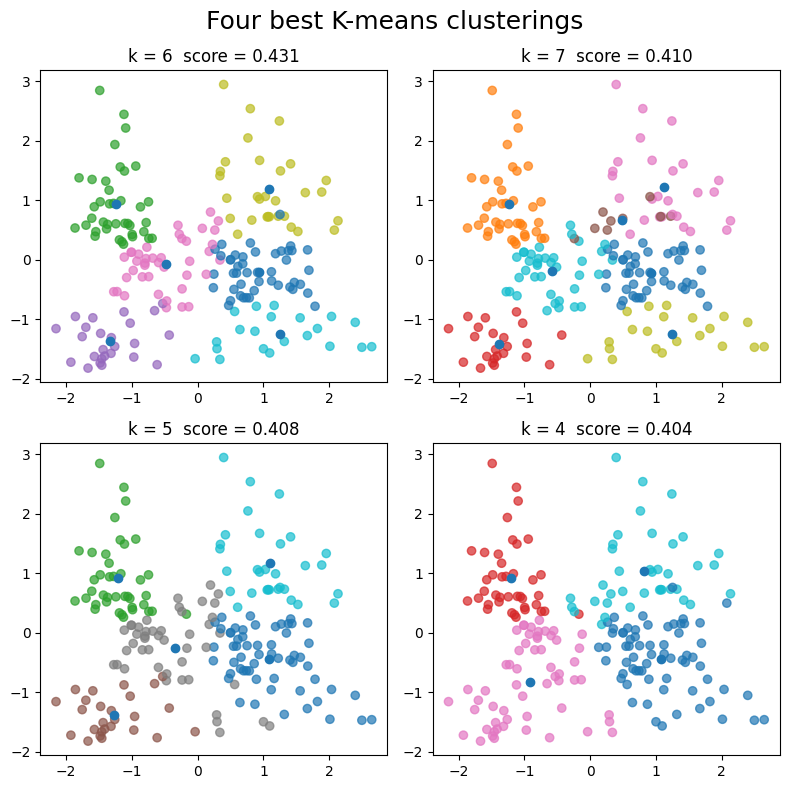

In [35]:
# use the same plot layout as 8 c, 8 d
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Four best K-means clusterings", fontsize=18)

axes = axes.flatten()

for i, ax in enumerate(axes):
    k = top4_k[i]

    #re-fit the model
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(data_standardized)
    
    #score
    score = silhouette_score(data_standardized, labels)

    # scatter plot data in PCA space
    ax.scatter(pca_df["PC1"], pca_df["PC2"], c=labels, cmap="tab10", alpha=0.7)

    #transform centroids
    centroids = centroid_dict[k]
    centroids_pca = pca.transform(centroids)

    # plot centroids
    ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1])

    ax.set_title(f"k = {k}  score = {score:.3f}")

plt.tight_layout()
plt.show()

The K-means centroids are computed in the standardized feature space, not in the PCA space, also the scatter plot is in PCA space. If I plot the centroids directly, their coordinates will be meaningless and will not appear at the right locations relative to the data points. To plot centroids correctly, we must project them using the same PCA transformation as the data to make sure the centroids appear in the same coordinate system as the PCA scatter plot.

## Interpretation

Earlier, we were able to see some patterns in behaviour by manual exploration and handcrafted features. Let's try to interpret the automatically created clustering now


- select the best clustering result from either K-means or agglomerative. One way to choose would again be based on the silhouette score.
- assign the cluster labels to the variable `labels` 
- create a dataframe with the column `cluster` as the labels from the clustering  and the numerical features as the other columns using the ready-made code below


In [36]:

best_linkage = "ward"
best_n_clusters = 5

model = AgglomerativeClustering(n_clusters=best_n_clusters, linkage=best_linkage)
labels = model.fit_predict(data_standardized)

In [37]:
# run this ready-made code to create the dataframe.
spending = pd.DataFrame({"cluster": labels, "spending": data["spending_score"],
                         "age": data["age"], "income": data["income"]})



Create a boxplot of the spending dataframe with column "cluster" as the x axis and "spending" as the y axis. This is very easy to do with Seaborn.

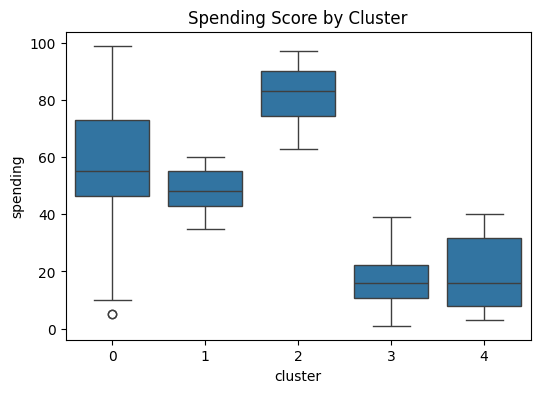

In [38]:

plt.figure(figsize=(6,4))
sns.boxplot(data=spending, x="cluster", y="spending")
plt.title("Spending Score by Cluster")
plt.show()


Create a boxplot of the spending dataframe with column "cluster" as the x axis and "age" as the y axis.

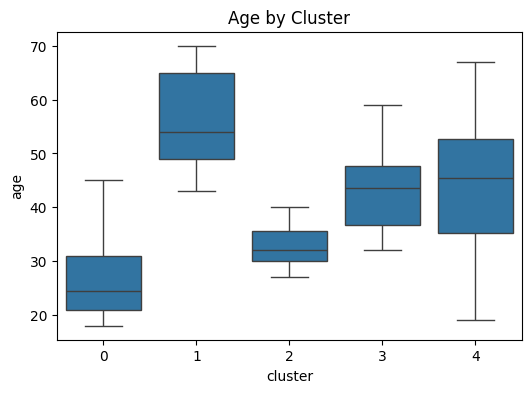

In [39]:

plt.figure(figsize=(6,4))
sns.boxplot(data=spending, x="cluster", y="age")
plt.title("Age by Cluster")
plt.show()



Create a boxplot of the spending dataframe with column "cluster" as the x axis and "income" as the y axis.

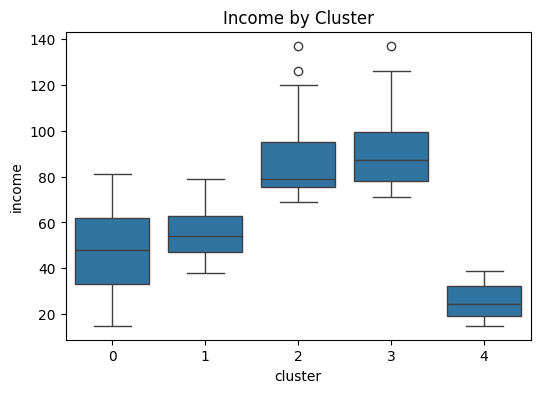

In [40]:

plt.figure(figsize=(6,4))
sns.boxplot(data=spending, x="cluster", y="income")
plt.title("Income by Cluster")
plt.show()

- The boxplots show that the clusters represent different demographic groups with different behaviour. We can see that some clusters contain customers who have higher incomes and higher spending scores, and others include mostly older customers with low spending.

- These clusters represent the same patterns. The automatically discovered clusters reflect the same general patterns, such as: A group of older customers with moderate spending; A group of high-income but conservative spenders.


## Using categorical features

Gender seems like a good attribute to segment customers by. We have not used the `gender` attribute up to this point. Why not?

Clustering is about the similarity of data points. For our algorithms we define similarity through distance measures. But what is the distance between "Female" and "Male" genders? Also, is this distance smaller or bigger than the distance between ages 24 and 44? These questions do not have meaningful general answers, but to use e.g. K-means we need to provide some numeric value.

There is no single correct solution to this problem. It is not even certain that including gender improves the results of the segmentation. Try to find something that works with our shopping center data set.




Create a clustering that makes good use of both the numerical features and the gender attribute.

- use one-hot encoding to convert the `gender` to a numerical feature. Cluster "as is" and draw conclusions
- we can use techniques we used with agglomerative and k-means clustering exercises to find some solution to the distance problem discussed above


In [41]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler

#One-hot encode gender
encoder = OneHotEncoder(sparse_output=False, drop=None)
gender_encoded = encoder.fit_transform(data[["gender"]])
gender_df = pd.DataFrame(gender_encoded, columns=encoder.get_feature_names_out(["gender"]))

Since gender is a categorical variable (“Male”, “Female”), K-means cannot work with it directly because K-means only understands numbers. So I convert the gender column into binary columns (0/1). This is called one-hot encoding.
sparse=False makes the output a normal array instead of a sparse matrix.
The result becomes two new columns: gender_Female and gender_Male.



In [42]:
#Combine numerical + gender features
num_features = ["age", "income", "spending_score"]
data_combined = pd.concat([data[num_features], gender_df], axis=1)

I take the three original numeric variables and stick the encoded gender columns next to them. So now the dataset contains all five features that I want to include in clustering.

In [43]:
#Standardize everything
scaler = StandardScaler()
X_combined = scaler.fit_transform(data_combined)

Since K-means is sensitive to scale, so this step is mandatory.

In [44]:
#Try K-means for 2–10 clusters
scores = {}
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=0)
    labels = model.fit_predict(X_combined)
    score = silhouette_score(X_combined, labels)
    scores[k] = score

I want to find out how many clusters make the most sense. So I try all values from k = 2 to 10, and measure how good the clustering is using the silhouette score, which tells me how well-separated and meaningful the clusters are.

Higher silhouette score = better clustering.

In [45]:
#Best k
best_k = max(scores, key=scores.get)

#Run K-means one more time to get the final cluster labels for each customer
final_model = KMeans(n_clusters=best_k, random_state=0)
final_labels = final_model.fit_predict(X_combined)

#add the cluster labels back into the original dataset to inspect what type of customers appear in each cluster.
bonus_df = data.copy()
bonus_df["cluster"] = final_labels

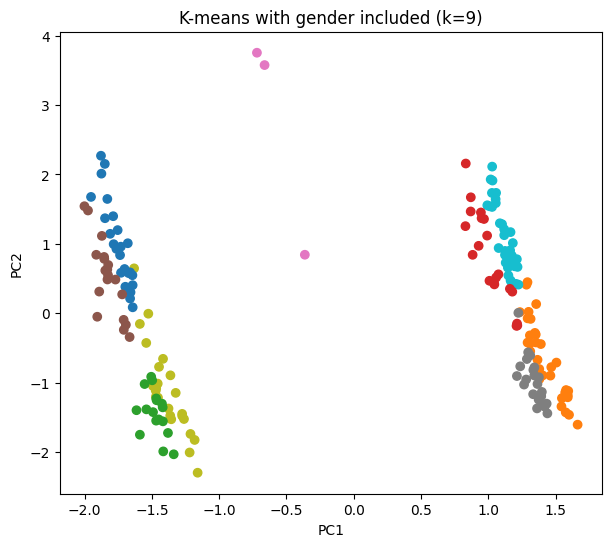

In [46]:
#Using PCA to reduce it to 2 dimensions scatter plot
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

#plot
plt.figure(figsize=(7,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=final_labels, cmap="tab10")
plt.title(f"K-means with gender included (k={best_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()